In [21]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

In [22]:
df = pd.read_csv('../data/fraud_unsupervised_results.csv')

fraud_df = df[df['fraud_flag'] == 1].copy()

print("Fraud cases:", fraud_df.shape)

Fraud cases: (10134, 441)


In [23]:
# Weighted Graph
G = nx.Graph()

for _, row in fraud_df.iterrows():
    
    card = f"card_{row['card1']}"
    
    if 'P_emaildomain' in fraud_df.columns:
        email = f"email_{row['P_emaildomain']}"
        
        if G.has_edge(card, email):
            G[card][email]['weight'] += 1
        else:
            G.add_edge(card, email, weight=1)
    
    if 'DeviceType' in fraud_df.columns:
        device = f"device_{row['DeviceType']}"
        
        if G.has_edge(card, device):
            G[card][device]['weight'] += 1
        else:
            G.add_edge(card, device, weight=1)

In [24]:
# Community Detection
from networkx.algorithms import community

communities = list(community.greedy_modularity_communities(G))

print("Total communities:", len(communities))

Total communities: 6


In [25]:
large_communities = [c for c in communities if len(c) > 5]

print("Large fraud groups:", len(large_communities))

Large fraud groups: 6


In [26]:
# Centrality Measures

degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)

# Combine scores
node_scores = {}

for node in G.nodes():
    node_scores[node] = (
        degree_centrality.get(node, 0) +
        betweenness.get(node, 0)
    )

# Top fraud hubs
top_hubs = sorted(node_scores.items(), key=lambda x: x[1], reverse=True)[:10]

top_hubs

[('device_0.0', 1.2073795340556843),
 ('device_2.0', 0.7518971744590801),
 ('email_16.0', 0.6034007340966018),
 ('email_1.0', 0.33333043620790115),
 ('email_31.0', 0.31396390378148215),
 ('email_55.0', 0.2524532979359929),
 ('device_1.0', 0.1731006811447682),
 ('email_19.0', 0.10867746733073465),
 ('email_2.0', 0.10584980912889654),
 ('email_9.0', 0.04861825190564598)]

In [27]:
# Score Communities
community_data = []

for i, comm in enumerate(communities):
    
    size = len(comm)
    
    # total connections
    edges = G.subgraph(comm).number_of_edges()
    
    score = size * edges  # simple fraud score
    
    community_data.append({
        'community_id': i,
        'size': size,
        'edges': edges,
        'fraud_score': score
    })

community_df = pd.DataFrame(community_data)

community_df.sort_values('fraud_score', ascending=False).head()

,community_id,size,edges,fraud_score
1,1,499,972,485028
0,0,514,513,263682
3,3,329,716,235564
2,2,424,517,219208
4,4,261,260,67860


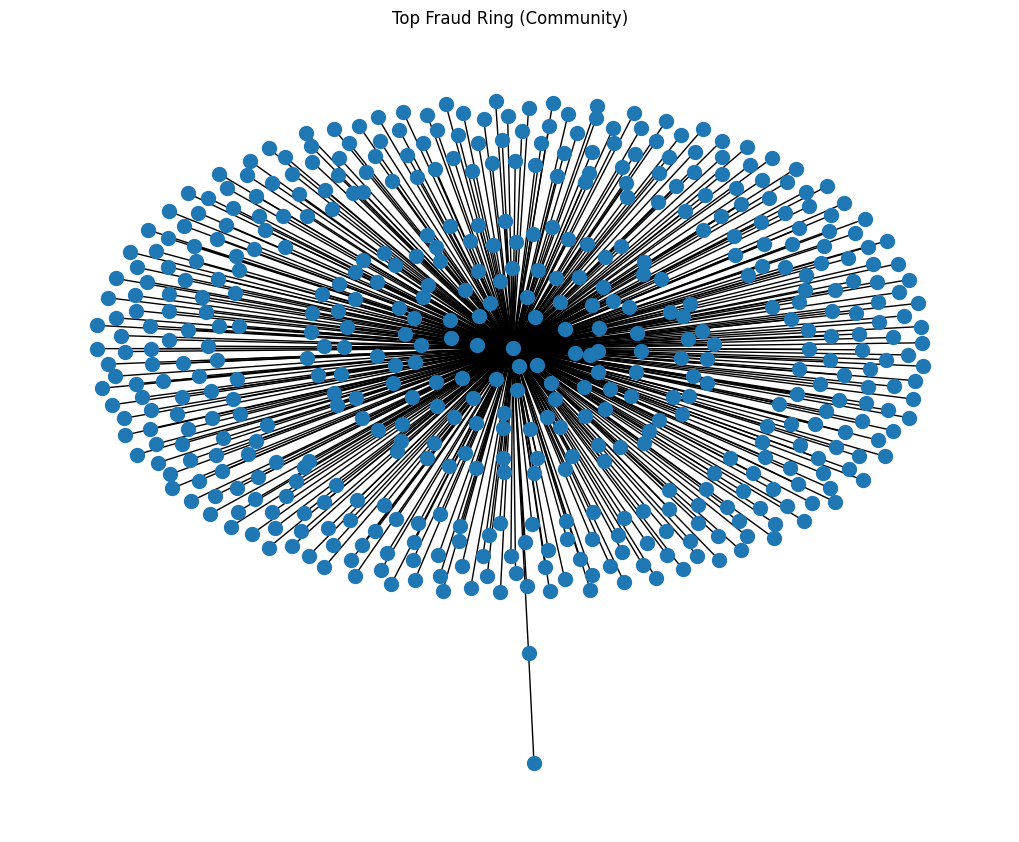

In [28]:
# Visualize Top Community

top_comm = max(communities, key=len)

subG = G.subgraph(top_comm)

plt.figure(figsize=(10,8))

pos = nx.spring_layout(subG)

nx.draw(subG, pos,
        node_size=100,
        with_labels=False)

plt.title("Top Fraud Ring (Community)")
plt.show()

In [29]:
# Node Table

node_df = pd.DataFrame({
    'node': list(node_scores.keys()),
    'risk_score': list(node_scores.values())
})

node_df.sort_values('risk_score', ascending=False).head(20)

,node,risk_score
5,device_0.0,1.207380
2,device_2.0,0.751897
4,email_16.0,0.603401
20,email_1.0,0.333330
19,email_31.0,0.313964
7,email_55.0,0.252453
15,device_1.0,0.173101
14,email_19.0,0.108677
17,email_2.0,0.105850
37,email_9.0,0.048618


In [30]:
community_df.to_csv('../data/fraud_communities.csv', index=False)
node_df.to_csv('../data/fraud_nodes.csv', index=False)